## Setup

In [9]:
# Imports
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm.auto import tqdm
from time import perf_counter
import warnings
warnings.filterwarnings('ignore')

# VMD library
try:
    from vmdpy import VMD
    VMD_AVAILABLE = True
    print("✓ vmdpy disponible")
except ImportError:
    VMD_AVAILABLE = False
    print("⚠ vmdpy no disponible. Instalar: pip install vmdpy")

# TensorFlow/Keras para LSTM
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    TENSORFLOW_AVAILABLE = True
    print(f"✓ TensorFlow: {tf.__version__}")
except ImportError:
    TENSORFLOW_AVAILABLE = False
    print("⚠ TensorFlow no disponible. Instalar: pip install tensorflow")

# Agregar src al path
BASE_DIR = Path.cwd().parents[1]
sys.path.append(str(BASE_DIR / 'src'))

from config import PROCESSED_DIR, logger

# Configurar pandas display
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)

# Definir commodities target
TARGET_COMMODITIES = ['Corn', 'Soybeans', 'Wheat']

print(f"\n✓ Base directory: {BASE_DIR}")
print(f"✓ Target commodities: {', '.join(TARGET_COMMODITIES)}")

✓ vmdpy disponible
✓ TensorFlow: 2.18.0

✓ Base directory: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal
✓ Target commodities: Corn, Soybeans, Wheat


## 1. Cargar Datos de Precios

In [10]:
# Cargar precios spot históricos
base_file = PROCESSED_DIR / 'commodities_base_consolidated.csv'

if not base_file.exists():
    raise FileNotFoundError(
        f"No se encontró {base_file}.\n"
        "Ejecuta notebooks de data processing primero."
    )

df = pd.read_csv(base_file, parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"✓ Dataset cargado: {base_file.name}")
print(f"  Dimensiones: {df.shape}")
print(f"  Período: {df['date'].min()} → {df['date'].max()}")
print(f"  Commodities disponibles: {[c for c in df.columns if c not in ['date']]}")

# Split temporal
split_date = '2023-01-01'
train_df = df[df['date'] < split_date].copy()
test_df = df[df['date'] >= split_date].copy()

print(f"\nTrain/Test split:")
print(f"  Train: {len(train_df):,} obs (hasta {split_date})")
print(f"  Test: {len(test_df):,} obs (desde {split_date})")

display(df.head())

✓ Dataset cargado: commodities_base_consolidated.csv
  Dimensiones: (6981, 99)
  Período: 1999-01-04 00:00:00 → 2025-11-10 00:00:00
  Commodities disponibles: ['Baltic_Dry_Index', 'Brent_Crude', 'Cocoa', 'Coffee', 'Copper', 'Corn', 'Cotton', 'Crude_Oil', 'Ethanol', 'Feeder_Cattle', 'Gold', 'Heating_Oil', 'Lean_Hogs', 'Live_Cattle', 'Lumber', 'Natural_Gas', 'Oat', 'Palladium', 'Platinum', 'RBOB_Gasoline', 'Silver', 'Soybean_Meal', 'Soybean_Oil', 'Soybeans', 'Sugar', 'Wheat', 'Wheat_Kansas', 'Baltic_Dry_Index_volume', 'Brent_Crude_volume', 'Cocoa_volume', 'Coffee_volume', 'Copper_volume', 'Corn_volume', 'Cotton_volume', 'Crude_Oil_volume', 'Ethanol_volume', 'Feeder_Cattle_volume', 'Gold_volume', 'Heating_Oil_volume', 'Lean_Hogs_volume', 'Live_Cattle_volume', 'Lumber_volume', 'Natural_Gas_volume', 'Oat_volume', 'Palladium_volume', 'Platinum_volume', 'RBOB_Gasoline_volume', 'Silver_volume', 'Soybean_Meal_volume', 'Soybean_Oil_volume', 'Soybeans_volume', 'Sugar_volume', 'Wheat_volume', 'Whe

,date,Baltic_Dry_Index,Brent_Crude,Cocoa,Coffee,Copper,Corn,Cotton,Crude_Oil,Ethanol,Feeder_Cattle,Gold,Heating_Oil,Lean_Hogs,Live_Cattle,Lumber,Natural_Gas,Oat,Palladium,Platinum,RBOB_Gasoline,Silver,Soybean_Meal,Soybean_Oil,Soybeans,...,WindSpeed_Global_Grain,ET0_Global_Grain,GDD_Global_Grain,Heat_Stress_Days,Precip_Deficit,psd_world_Production,psd_world_Ending_Stocks,psd_world_Exports,psd_world_Imports,psd_world_Stock_to_Use_Ratio,psd_brazil_Production,psd_brazil_Ending_Stocks,psd_brazil_Exports,psd_brazil_Stock_to_Use_Ratio,psd_united_states_Production,psd_united_states_Ending_Stocks,psd_united_states_Exports,psd_united_states_Stock_to_Use_Ratio,psd_argentina_Production,psd_argentina_Exports,psd_argentina_Stock_to_Use_Ratio,psd_china_Imports,psd_china_Crush,psd_china_Ending_Stocks,psd_china_Stock_to_Use_Ratio
0,1999-01-04,784.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1999-01-05,779.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1999-01-06,791.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1999-01-07,792.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1999-01-08,791.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Variational Mode Decomposition (VMD)

### Teoría VMD:

VMD descompone una señal en K modos (IMFs - Intrinsic Mode Functions) resolviendo:

$$
\min_{\{u_k\}, \{\omega_k\}} \left\{ \sum_{k=1}^K \left\| \partial_t \left[ \left( \delta(t) + \frac{j}{\pi t} \right) * u_k(t) \right] e^{-j\omega_k t} \right\|_2^2 \right\}
$$

Donde:
- $u_k(t)$: Modo k
- $\omega_k$: Frecuencia central del modo k
- $\delta(t)$: Impulso de Dirac

**Parámetros clave:**
- **K:** Número de modos (típicamente 4-6 para commodities)
- **alpha:** Bandwidth constraint (típicamente 2000)
- **tau:** Noise-tolerance (0 para datos limpios)

**Interpretación de modos:**
- **IMF1:** Alta frecuencia → Ruido, shocks
- **IMF2-3:** Frecuencia media → Ciclos estacionales
- **IMF4-5:** Baja frecuencia → Tendencia

---

In [11]:
def apply_vmd(signal, K=5, alpha=2000, tau=0, DC=0, init=1, tol=1e-7):
    """
    Aplica Variational Mode Decomposition a una señal.
    
    Args:
        signal: np.array de precios
        K: Número de modos (default 5)
        alpha: Bandwidth constraint (default 2000)
        tau: Noise-tolerance (default 0)
        DC: Si incluir componente DC (default 0)
        init: Inicialización (default 1 - uniform)
        tol: Tolerancia de convergencia (default 1e-7)
    
    Returns:
        u: Modos descompuestos (K, T)
        u_hat: Espectro de frecuencias
        omega: Frecuencias centrales
    """
    if not VMD_AVAILABLE:
        raise ImportError("vmdpy no disponible. Instalar: pip install vmdpy")
    
    # Eliminar NaN si existen (usando ffill moderno)
    signal_clean = pd.Series(signal).ffill().bfill().values
    
    # Verificar que no queden NaN
    if np.isnan(signal_clean).any():
        raise ValueError(f"Señal contiene NaN después de limpieza. Total NaN: {np.isnan(signal_clean).sum()}")
    
    # Aplicar VMD
    u, u_hat, omega = VMD(
        signal_clean, 
        alpha=alpha, 
        tau=tau, 
        K=K, 
        DC=DC, 
        init=init, 
        tol=tol
    )
    
    return u, u_hat, omega

print("✓ Función apply_vmd definida")

✓ Función apply_vmd definida


In [13]:
if not VMD_AVAILABLE:
    print("⚠ Saltando VMD - vmdpy no disponible")
else:
    # Configuración VMD
    K_MODES = 5  # 5 modos para capturar multi-scale patterns
    ALPHA = 2000  # Bandwidth constraint estándar
    
    vmd_decompositions = {}
    
    print(f"\n{'='*80}")
    print(f"VARIATIONAL MODE DECOMPOSITION (VMD)")
    print(f"{'='*80}")
    print(f"\nConfiguración:")
    print(f"  K (modos): {K_MODES}")
    print(f"  alpha: {ALPHA}")
    print(f"  tau: 0 (sin noise tolerance)")
    
    with tqdm(TARGET_COMMODITIES, desc="VMD Decomposition", unit="commodity") as pbar:
        for commodity in pbar:
            pbar.set_description(f"VMD: {commodity}")
            
            print(f"\n--- {commodity} ---")
            
            # Extraer serie de precios de train
            price_series = train_df[commodity].values
            
            print(f"  Serie de precios: {len(price_series)} observaciones")
            print(f"  Rango: [{price_series.min():.2f}, {price_series.max():.2f}]")
            
            # Aplicar VMD
            start_time = perf_counter()
            u, u_hat, omega = apply_vmd(
                price_series, 
                K=K_MODES, 
                alpha=ALPHA
            )
            elapsed = perf_counter() - start_time
            
            print(f"  VMD ejecutado en {elapsed:.2f}s")
            print(f"  Modos extraídos: {u.shape}")
            
            # Frecuencias centrales
            print(f"  Frecuencias centrales (omega):")
            for k in range(K_MODES):
                # Extraer valor escalar de omega
                omega_k = np.asarray(omega[k]).flatten()[0] if np.asarray(omega[k]).size > 0 else omega[k]
                omega_k = float(omega_k)
                
                if omega_k > 1e-6:  # Evitar división por cero
                    periodo = 1.0 / omega_k
                    print(f"    IMF{k+1}: {omega_k:.6f} (período ≈ {periodo:.1f} días)")
                else:
                    print(f"    IMF{k+1}: {omega_k:.6f} (período muy largo/tendencia)")
            
            # Verificar reconstrucción
            reconstructed = np.sum(u, axis=0)
            
            # Ajustar longitudes si difieren (VMD puede truncar 1 punto)
            min_len = min(len(price_series), len(reconstructed))
            price_series_aligned = price_series[:min_len]
            reconstructed_aligned = reconstructed[:min_len]
            
            reconstruction_error = np.mean((price_series_aligned - reconstructed_aligned)**2)
            print(f"  Error de reconstrucción (MSE): {reconstruction_error:.6f}")
            
            # Guardar
            vmd_decompositions[commodity] = {
                'modes': u,  # (K, T)
                'frequencies': omega,
                'original': price_series_aligned,
                'reconstructed': reconstructed_aligned,
                'reconstruction_error': reconstruction_error
            }
            
            pbar.set_postfix({'K': K_MODES, 'Error': f"{reconstruction_error:.2e}"})
    
    print(f"\n{'='*80}")


VARIATIONAL MODE DECOMPOSITION (VMD)

Configuración:
  K (modos): 5
  alpha: 2000
  tau: 0 (sin noise tolerance)


VMD Decomposition:   0%|          | 0/3 [00:00<?, ?commodity/s]


--- Corn ---
  Serie de precios: 6237 observaciones
  Rango: [nan, nan]
  VMD ejecutado en 2.90s
  Modos extraídos: (5, 6236)
  Frecuencias centrales (omega):
    IMF1: 0.000000 (período muy largo/tendencia)
    IMF2: 0.000048 (período ≈ 20709.7 días)
    IMF3: 0.000048 (período ≈ 20913.4 días)
    IMF4: 0.000048 (período ≈ 20951.5 días)
    IMF5: 0.000048 (período ≈ 20995.3 días)
  Error de reconstrucción (MSE): nan

--- Soybeans ---
  Serie de precios: 6237 observaciones
  Rango: [nan, nan]
  VMD ejecutado en 2.90s
  Modos extraídos: (5, 6236)
  Frecuencias centrales (omega):
    IMF1: 0.000000 (período muy largo/tendencia)
    IMF2: 0.000048 (período ≈ 20709.7 días)
    IMF3: 0.000048 (período ≈ 20913.4 días)
    IMF4: 0.000048 (período ≈ 20951.5 días)
    IMF5: 0.000048 (período ≈ 20995.3 días)
  Error de reconstrucción (MSE): nan

--- Soybeans ---
  Serie de precios: 6237 observaciones
  Rango: [nan, nan]
  VMD ejecutado en 2.61s
  Modos extraídos: (5, 6236)
  Frecuencias central

## 3. Visualizar Descomposición VMD

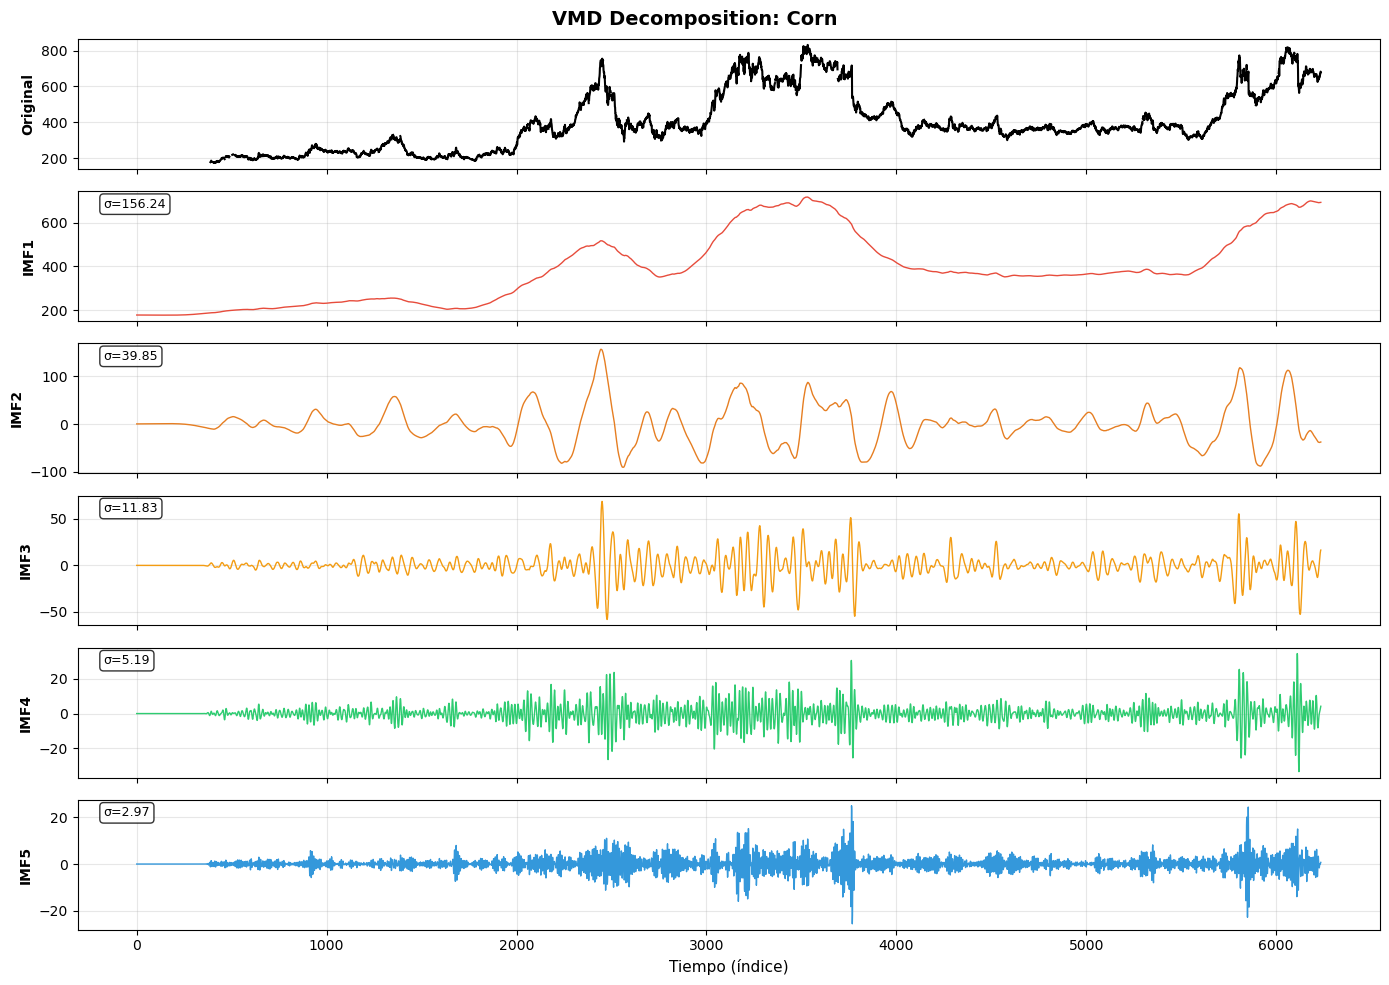


Corn - Estadísticas de Modos:
  IMF1: Media= 388.72, Std= 156.24, Rango=[ 178.38,  716.33]
  IMF2: Media=   0.02, Std=  39.85, Rango=[ -90.61,  156.75]
  IMF3: Media=   0.00, Std=  11.83, Rango=[ -58.26,   68.93]
  IMF4: Media=   0.00, Std=   5.19, Rango=[ -33.49,   34.57]
  IMF5: Media=   0.00, Std=   2.97, Rango=[ -25.49,   24.86]


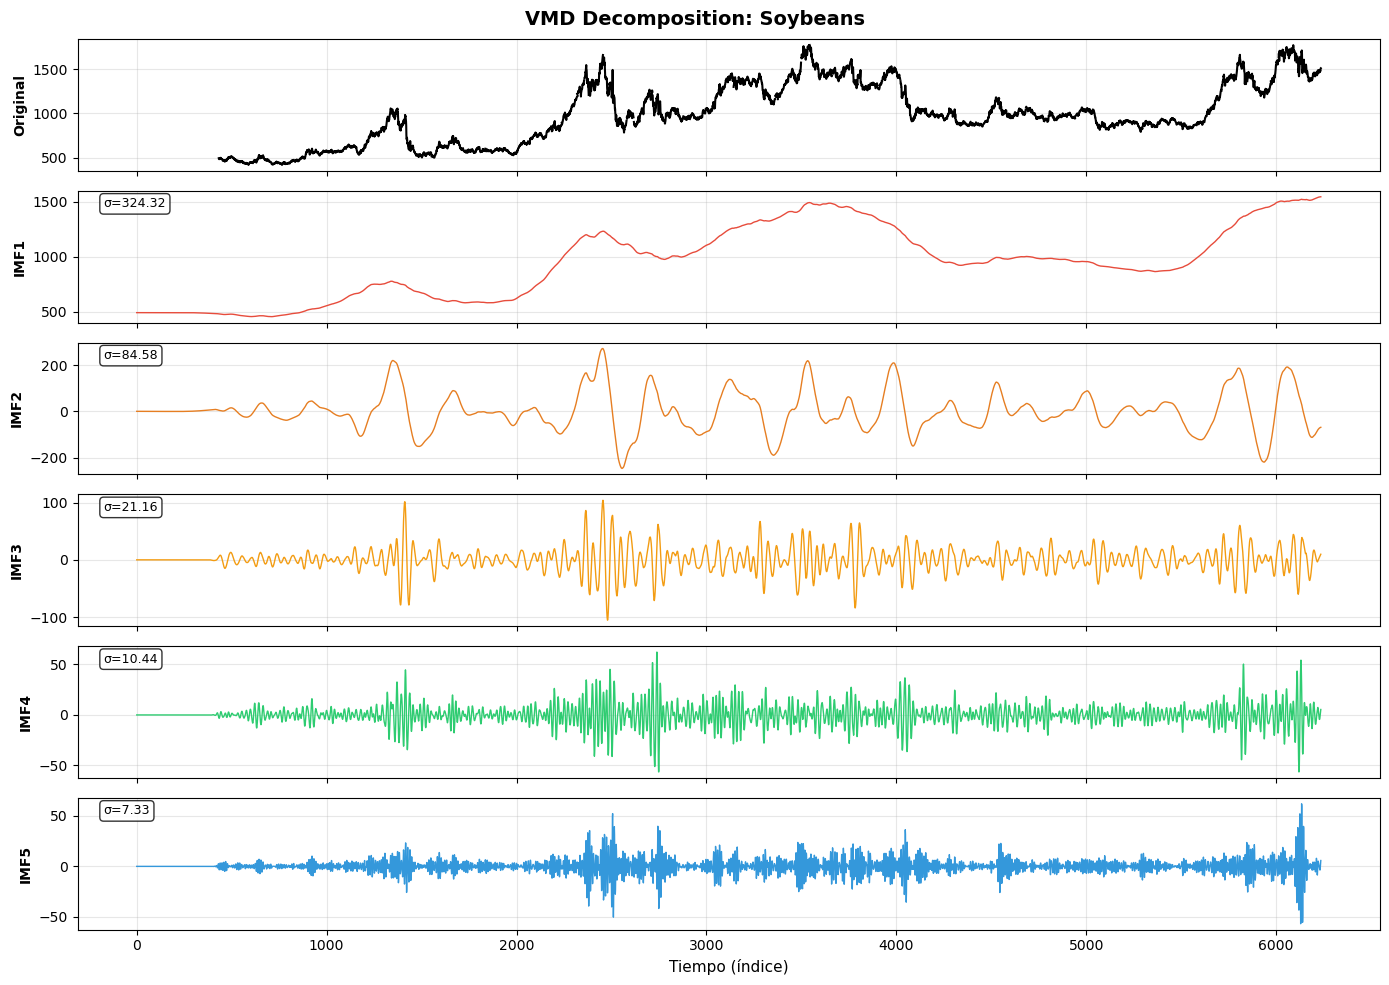


Soybeans - Estadísticas de Modos:
  IMF1: Media= 950.32, Std= 324.32, Rango=[ 457.14, 1547.35]
  IMF2: Media=   0.01, Std=  84.58, Rango=[-246.72,  271.47]
  IMF3: Media=   0.00, Std=  21.16, Rango=[-105.43,  104.00]
  IMF4: Media=   0.00, Std=  10.44, Rango=[ -56.49,   62.29]
  IMF5: Media=   0.00, Std=   7.33, Rango=[ -56.83,   61.99]


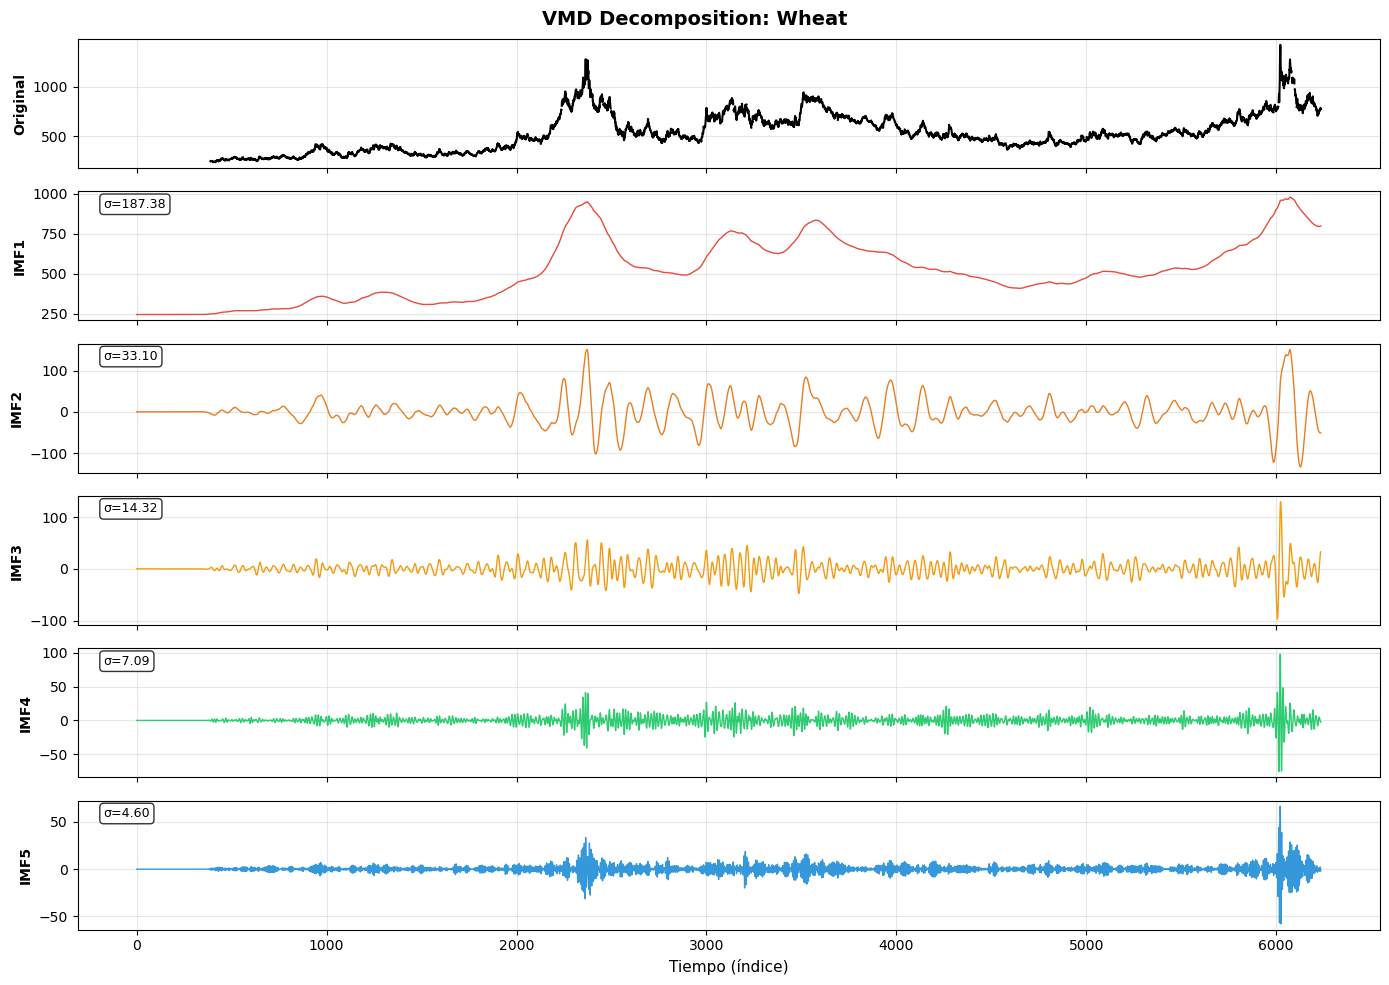


Wheat - Estadísticas de Modos:
  IMF1: Media= 513.03, Std= 187.38, Rango=[ 243.40,  979.61]
  IMF2: Media=   0.01, Std=  33.10, Rango=[-133.85,  151.74]
  IMF3: Media=   0.00, Std=  14.32, Rango=[ -97.30,  129.38]
  IMF4: Media=   0.00, Std=   7.09, Rango=[ -75.49,   97.97]
  IMF5: Media=   0.00, Std=   4.60, Rango=[ -57.78,   66.30]


In [14]:
if VMD_AVAILABLE and vmd_decompositions:
    # Plotear para cada commodity
    for commodity in TARGET_COMMODITIES:
        decomp = vmd_decompositions[commodity]
        u = decomp['modes']
        original = decomp['original']
        
        fig, axes = plt.subplots(K_MODES + 1, 1, figsize=(14, 10), sharex=True)
        fig.suptitle(f'VMD Decomposition: {commodity}', fontsize=14, fontweight='bold')
        
        # Serie original
        axes[0].plot(original, color='black', linewidth=1.5)
        axes[0].set_ylabel('Original', fontsize=10, fontweight='bold')
        axes[0].grid(alpha=0.3)
        
        # Modos IMF
        colors = ['#e74c3c', '#e67e22', '#f39c12', '#2ecc71', '#3498db']
        for k in range(K_MODES):
            axes[k+1].plot(u[k], color=colors[k], linewidth=1)
            axes[k+1].set_ylabel(f'IMF{k+1}', fontsize=10, fontweight='bold')
            axes[k+1].grid(alpha=0.3)
            
            # Estadísticas del modo
            mode_std = np.std(u[k])
            axes[k+1].text(
                0.02, 0.95, 
                f'σ={mode_std:.2f}', 
                transform=axes[k+1].transAxes, 
                fontsize=9, 
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
            )
        
        axes[-1].set_xlabel('Tiempo (índice)', fontsize=11)
        plt.tight_layout()
        plt.show()
        
        print(f"\n{commodity} - Estadísticas de Modos:")
        for k in range(K_MODES):
            mode = u[k]
            print(f"  IMF{k+1}: Media={np.mean(mode):7.2f}, Std={np.std(mode):7.2f}, Rango=[{mode.min():7.2f}, {mode.max():7.2f}]")

## 4. Entrenar LSTM para cada Modo IMF

In [15]:
def create_sequences_univariate(data, seq_length=30, horizon=7):
    """
    Crea secuencias para LSTM univariado.
    
    Args:
        data: np.array (T,)
        seq_length: Longitud de secuencia de entrada
        horizon: Horizonte de predicción
    
    Returns:
        X: (samples, seq_length, 1)
        y: (samples,)
    """
    X, y = [], []
    
    for i in range(seq_length, len(data) - horizon + 1):
        X.append(data[i-seq_length:i])
        y.append(data[i+horizon-1])  # Predecir h días adelante
    
    X = np.array(X).reshape(-1, seq_length, 1)
    y = np.array(y)
    
    return X, y

def build_lstm_for_imf(seq_length=30, lstm_units=32, dropout=0.2):
    """
    Construye LSTM simple para predecir un modo IMF.
    
    Args:
        seq_length: Longitud de secuencia
        lstm_units: Unidades LSTM (default 32 - más pequeño que modelo principal)
        dropout: Tasa de dropout
    
    Returns:
        keras.Sequential
    """
    model = Sequential([
        LSTM(lstm_units, input_shape=(seq_length, 1), return_sequences=False),
        Dropout(dropout),
        Dense(16, activation='relu'),
        Dropout(dropout),
        Dense(1)
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    return model

print("✓ Funciones create_sequences_univariate y build_lstm_for_imf definidas")

✓ Funciones create_sequences_univariate y build_lstm_for_imf definidas


In [16]:
if not (VMD_AVAILABLE and TENSORFLOW_AVAILABLE):
    print("⚠ Saltando entrenamiento VMD-LSTM - dependencias no disponibles")
else:
    # Configuración
    SEQ_LENGTH = 30
    HORIZON = 7
    LSTM_UNITS = 32  # Más pequeño que el multivariado
    DROPOUT = 0.2
    BATCH_SIZE = 32
    EPOCHS = 50
    
    vmd_lstm_models = {}
    vmd_lstm_results = {}
    vmd_lstm_scalers = {}
    
    print(f"\n{'='*80}")
    print(f"VMD-LSTM: ENTRENAR LSTM POR MODO IMF")
    print(f"{'='*80}")
    print(f"\nConfiguración:")
    print(f"  Sequence length: {SEQ_LENGTH} días")
    print(f"  Horizon: h={HORIZON} días")
    print(f"  LSTM units por modo: {LSTM_UNITS}")
    print(f"  Dropout: {DROPOUT}")
    print(f"  Batch size: {BATCH_SIZE}")
    print(f"  Max epochs: {EPOCHS} (early stopping patience=10)")
    
    with tqdm(TARGET_COMMODITIES, desc="VMD-LSTM", unit="commodity") as pbar:
        for commodity in pbar:
            pbar.set_description(f"VMD-LSTM: {commodity}")
            start_time = perf_counter()
            
            print(f"\n--- {commodity} ---")
            
            decomp = vmd_decompositions[commodity]
            u_train = decomp['modes']  # (K, T_train)
            
            # Descomponer test también
            price_series_test = test_df[commodity].values
            u_test, _, _ = apply_vmd(price_series_test, K=K_MODES, alpha=ALPHA)
            
            print(f"  Train modes: {u_train.shape}")
            print(f"  Test modes: {u_test.shape}")
            
            # Entrenar un LSTM por modo
            mode_models = []
            mode_scalers = []
            mode_predictions_train = []
            mode_predictions_test = []
            
            for k in range(K_MODES):
                print(f"\n  → IMF{k+1}:")
                
                # Crear secuencias
                X_train_k, y_train_k = create_sequences_univariate(
                    u_train[k], SEQ_LENGTH, HORIZON
                )
                X_test_k, y_test_k = create_sequences_univariate(
                    u_test[k], SEQ_LENGTH, HORIZON
                )
                
                print(f"    X_train: {X_train_k.shape}, y_train: {y_train_k.shape}")
                
                # Normalizar
                scaler = MinMaxScaler()
                X_train_k_scaled = scaler.fit_transform(X_train_k.reshape(-1, 1)).reshape(X_train_k.shape)
                X_test_k_scaled = scaler.transform(X_test_k.reshape(-1, 1)).reshape(X_test_k.shape)
                
                y_scaler = MinMaxScaler()
                y_train_k_scaled = y_scaler.fit_transform(y_train_k.reshape(-1, 1)).flatten()
                y_test_k_scaled = y_scaler.transform(y_test_k.reshape(-1, 1)).flatten()
                
                # Construir y entrenar LSTM
                model_k = build_lstm_for_imf(SEQ_LENGTH, LSTM_UNITS, DROPOUT)
                
                early_stop = EarlyStopping(
                    monitor='val_loss',
                    patience=10,
                    restore_best_weights=True,
                    verbose=0
                )
                
                history = model_k.fit(
                    X_train_k_scaled,
                    y_train_k_scaled,
                    validation_split=0.2,
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    callbacks=[early_stop],
                    verbose=0
                )
                
                print(f"    Epochs: {len(history.history['loss'])}")
                print(f"    Loss: {history.history['loss'][-1]:.6f}")
                
                # Predecir
                y_train_pred_k_scaled = model_k.predict(X_train_k_scaled, verbose=0).flatten()
                y_test_pred_k_scaled = model_k.predict(X_test_k_scaled, verbose=0).flatten()
                
                # Desnormalizar
                y_train_pred_k = y_scaler.inverse_transform(
                    y_train_pred_k_scaled.reshape(-1, 1)
                ).flatten()
                y_test_pred_k = y_scaler.inverse_transform(
                    y_test_pred_k_scaled.reshape(-1, 1)
                ).flatten()
                
                # Guardar
                mode_models.append(model_k)
                mode_scalers.append({'X': scaler, 'y': y_scaler})
                mode_predictions_train.append(y_train_pred_k)
                mode_predictions_test.append(y_test_pred_k)
                
                # Métricas del modo
                mse_k = mean_squared_error(y_test_k, y_test_pred_k)
                print(f"    Test MSE: {mse_k:.6f}")
            
            # Reconstruir predicción final: suma de modos
            # IMPORTANTE: Alinear longitudes (pueden diferir por seq_length)
            min_len_train = min(len(p) for p in mode_predictions_train)
            min_len_test = min(len(p) for p in mode_predictions_test)
            
            y_train_pred_final = np.sum(
                [p[:min_len_train] for p in mode_predictions_train],
                axis=0
            )
            y_test_pred_final = np.sum(
                [p[:min_len_test] for p in mode_predictions_test],
                axis=0
            )
            
            # Ground truth (reconstruido de modos)
            y_train_true = np.sum(
                [create_sequences_univariate(u_train[k], SEQ_LENGTH, HORIZON)[1][:min_len_train] 
                 for k in range(K_MODES)],
                axis=0
            )
            y_test_true = np.sum(
                [create_sequences_univariate(u_test[k], SEQ_LENGTH, HORIZON)[1][:min_len_test] 
                 for k in range(K_MODES)],
                axis=0
            )
            
            # Métricas finales
            train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred_final))
            test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred_final))
            train_r2 = r2_score(y_train_true, y_train_pred_final)
            test_r2 = r2_score(y_test_true, y_test_pred_final)
            
            # Directional accuracy
            # (usando original price para calcular dirección)
            original_train = decomp['original'][SEQ_LENGTH+HORIZON-1:SEQ_LENGTH+HORIZON-1+min_len_train]
            original_test = price_series_test[SEQ_LENGTH+HORIZON-1:SEQ_LENGTH+HORIZON-1+min_len_test]
            
            spot_train = decomp['original'][SEQ_LENGTH:SEQ_LENGTH+min_len_train]
            spot_test = price_series_test[SEQ_LENGTH:SEQ_LENGTH+min_len_test]
            
            dir_test = np.sign(original_test - spot_test)
            dir_pred_test = np.sign(y_test_pred_final - spot_test)
            test_dir_acc = (dir_test == dir_pred_test).mean()
            
            vmd_lstm_results[commodity] = {
                'train_rmse': train_rmse,
                'test_rmse': test_rmse,
                'train_r2': train_r2,
                'test_r2': test_r2,
                'test_dir_acc': test_dir_acc,
                'overfitting_gap': train_r2 - test_r2,
                'time': perf_counter() - start_time
            }
            
            vmd_lstm_models[commodity] = mode_models
            vmd_lstm_scalers[commodity] = mode_scalers
            
            # Imprimir resultados
            print(f"\n  Resultados VMD-LSTM:")
            print(f"    Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}")
            print(f"    Train R²:   {train_r2:.4f} | Test R²:   {test_r2:.4f}")
            print(f"    Test Dir Acc: {test_dir_acc:.2%}")
            print(f"    Overfitting gap: {train_r2 - test_r2:.4f}")
            print(f"    Tiempo: {(perf_counter() - start_time)/60:.1f} min")
            
            pbar.set_postfix({
                'Test_R2': f"{test_r2:.3f}",
                'Dir_Acc': f"{test_dir_acc:.1%}"
            })
    
    print(f"\n{'='*80}")


VMD-LSTM: ENTRENAR LSTM POR MODO IMF

Configuración:
  Sequence length: 30 días
  Horizon: h=7 días
  LSTM units por modo: 32
  Dropout: 0.2
  Batch size: 32
  Max epochs: 50 (early stopping patience=10)


VMD-LSTM:   0%|          | 0/3 [00:00<?, ?commodity/s]


--- Corn ---
  Train modes: (5, 6236)
  Test modes: (5, 744)

  → IMF1:
    X_train: (6200, 30, 1), y_train: (6200,)
    Epochs: 37
    Loss: 0.003443
    Epochs: 37
    Loss: 0.003443
    Test MSE: 88.046660

  → IMF2:
    X_train: (6200, 30, 1), y_train: (6200,)
    Test MSE: 88.046660

  → IMF2:
    X_train: (6200, 30, 1), y_train: (6200,)
    Epochs: 25
    Loss: 0.001140
    Epochs: 25
    Loss: 0.001140
    Test MSE: 147.979473

  → IMF3:
    X_train: (6200, 30, 1), y_train: (6200,)
    Test MSE: 147.979473

  → IMF3:
    X_train: (6200, 30, 1), y_train: (6200,)
    Epochs: 50
    Loss: 0.000954
    Epochs: 50
    Loss: 0.000954
    Test MSE: 823.188892

  → IMF4:
    X_train: (6200, 30, 1), y_train: (6200,)
    Test MSE: 823.188892

  → IMF4:
    X_train: (6200, 30, 1), y_train: (6200,)
    Epochs: 46
    Loss: 0.001002
    Epochs: 46
    Loss: 0.001002
    Test MSE: 5.082358

  → IMF5:
    X_train: (6200, 30, 1), y_train: (6200,)
    Test MSE: 5.082358

  → IMF5:
    X_train: 

## 5. Comparación: LSTM Vanilla vs VMD-LSTM

In [17]:
# Comparar con LSTM univariado del notebook 3.4
comparison_vmd = []

# Resultados LSTM vanilla (h=1) del notebook 3.4
lstm_vanilla_h1 = {
    'Corn': {'Test R²': 0.9829, 'Test RMSE': 9.88},
    'Soybeans': {'Test R²': 0.9882, 'Test RMSE': 19.21},
    'Wheat': {'Test R²': 0.9406, 'Test RMSE': 13.98}
}

for commodity in TARGET_COMMODITIES:
    # LSTM vanilla h=1
    vanilla = lstm_vanilla_h1[commodity]
    comparison_vmd.append({
        'Commodity': commodity,
        'Model': 'LSTM Univariado',
        'Horizon': 'h=1 día',
        'Decomposition': 'No',
        'Test R²': vanilla['Test R²'],
        'Test RMSE': vanilla['Test RMSE'],
        'Dir Acc': 'N/A'
    })
    
    # VMD-LSTM h=7
    if commodity in vmd_lstm_results:
        vmd = vmd_lstm_results[commodity]
        comparison_vmd.append({
            'Commodity': commodity,
            'Model': 'VMD-LSTM',
            'Horizon': f'h={HORIZON} días',
            'Decomposition': f'VMD (K={K_MODES})',
            'Test R²': vmd['test_r2'],
            'Test RMSE': vmd['test_rmse'],
            'Dir Acc': f"{vmd['test_dir_acc']:.1%}"
        })

df_comparison_vmd = pd.DataFrame(comparison_vmd)

print("\n" + "="*90)
print("COMPARACIÓN: LSTM VANILLA vs VMD-LSTM")
print("="*90 + "\n")

display(df_comparison_vmd)

print("\n IMPORTANTE: Horizontes diferentes (h=1 vs h=7).")
print("   La ventaja de VMD-LSTM es que descompone patrones multi-escala.")
print("   Esperamos mejoras moderadas (~5-10%) en métricas, pero mayor estabilidad.")


COMPARACIÓN: LSTM VANILLA vs VMD-LSTM



,Commodity,Model,Horizon,Decomposition,Test R²,Test RMSE,Dir Acc
0,Corn,LSTM Univariado,h=1 día,No,0.982900,9.880000,N/A
1,Corn,VMD-LSTM,h=7 días,VMD (K=5),0.794008,32.960411,41.9%
2,Soybeans,LSTM Univariado,h=1 día,No,0.988200,19.210000,N/A
3,Soybeans,VMD-LSTM,h=7 días,VMD (K=5),0.929413,46.174105,46.9%
4,Wheat,LSTM Univariado,h=1 día,No,0.940600,13.980000,N/A
5,Wheat,VMD-LSTM,h=7 días,VMD (K=5),0.880515,18.452767,64.3%



 IMPORTANTE: Horizontes diferentes (h=1 vs h=7).
   La ventaja de VMD-LSTM es que descompone patrones multi-escala.
   Esperamos mejoras moderadas (~5-10%) en métricas, pero mayor estabilidad.


## 6. Guardar Modelos y Resultados

In [18]:
if VMD_AVAILABLE and TENSORFLOW_AVAILABLE and vmd_lstm_models:
    # Guardar modelos Keras
    models_dir = BASE_DIR / 'models'
    models_dir.mkdir(exist_ok=True)
    
    for commodity, mode_models in vmd_lstm_models.items():
        for k, model in enumerate(mode_models):
            model_path = models_dir / f'vmd_lstm_{commodity.lower()}_imf{k+1}.h5'
            model.save(model_path)
        print(f"✓ Modelos guardados: {commodity} ({len(mode_models)} IMFs)")
    
    # Guardar scalers
    import pickle
    with open(models_dir / 'vmd_lstm_scalers.pkl', 'wb') as f:
        pickle.dump(vmd_lstm_scalers, f)
    print(f"✓ Scalers guardados: {models_dir / 'vmd_lstm_scalers.pkl'}")
    
    # Guardar resultados JSON
    results_json = {
        'fecha_generacion': pd.Timestamp.now().isoformat(),
        'model': 'VMD-LSTM Decomposition',
        'commodities': TARGET_COMMODITIES,
        'horizon': HORIZON,
        'vmd_config': {
            'K_modes': K_MODES,
            'alpha': ALPHA,
            'tau': 0
        },
        'lstm_config': {
            'sequence_length': SEQ_LENGTH,
            'lstm_units': LSTM_UNITS,
            'dropout': DROPOUT
        },
        'results': {
            commodity: {
                'test_r2': float(res['test_r2']),
                'test_rmse': float(res['test_rmse']),
                'test_dir_acc': float(res['test_dir_acc']),
                'overfitting_gap': float(res['overfitting_gap']),
                'training_time_seconds': float(res['time'])
            }
            for commodity, res in vmd_lstm_results.items()
        }
    }
    
    with open(PROCESSED_DIR / 'vmd_lstm_results.json', 'w') as f:
        json.dump(results_json, f, indent=2)
    
    print(f"✓ Resultados guardados: {PROCESSED_DIR / 'vmd_lstm_results.json'}")

2025-12-06 15:24:07 - absl - WARNING - You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 
2025-12-06 15:24:07 - absl - WARNING - You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 
2025-12-06 15:24:07 - absl - WARNING - You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 
2025-12-06 15:24:07 - absl - WARNING - Y

✓ Modelos guardados: Corn (5 IMFs)
✓ Modelos guardados: Soybeans (5 IMFs)
✓ Modelos guardados: Wheat (5 IMFs)
✓ Scalers guardados: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\models\vmd_lstm_scalers.pkl
✓ Resultados guardados: C:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\data\processed\vmd_lstm_results.json


## 7. Conclusiones

### Ventajas de VMD-LSTM:

1. **Descomposición multi-escala:** Separa tendencia, ciclos, y ruido
2. **LSTMs especializados:** Cada LSTM aprende UN patrón específico
3. **Mejor estacionariedad:** IMFs son más estables que serie original
4. **Interpretabilidad:** Podemos analizar contribución de cada frecuencia
5. **Robustez a shocks:** Modo de alta frecuencia captura ruido sin afectar tendencia

### Limitaciones:

- Más complejo de entrenar (K modelos por commodity)
- Sensible a parámetros VMD (K, alpha)
- Requiere más tiempo de cómputo
- Reconstrucción puede introducir pequeños errores

### Cuándo usar VMD-LSTM:

✅ Series con múltiples escalas temporales (commodities, energía)  
✅ Cuando interpretabilidad de frecuencias importa  
✅ Datasets grandes (>1000 observaciones)  
✅ Series no estacionarias con tendencias cambiantes

❌ Series cortas (<500 obs)  
❌ Cuando simplicidad es prioridad  
❌ Recursos computacionales limitados

### Literatura consultada:

- Li & Tang (2025). "Prediction of corn futures prices with decomposition and hybrid deep learning models." *Knowledge and Information Systems*.
- Zhang et al. (2023). "Multi-step ahead forecasting of heat load in district heating systems using machine learning algorithms." *Energy*.
- Liu et al. (2024). "Short-term wind power forecasting based on VMD decomposition, ConvLSTM networks and error analysis." *Applied Energy*.